# utils

In [15]:
import pandas as pd

def coefficient_of_variation(x):
    return x.std() / x.mean() if x.mean() != 0 else 0

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

### to merge multiple files

In [ ]:

# 개별 CSV 파일 읽기
df1 = pd.read_csv("/localdata2/esp/0419/offline/vllm_offline_nps4_cc_5000_2025-04-24/vllm_offline_nps4_cc_2025-04-24.csv")
df2 = pd.read_csv("/localdata2/esp/0419/offline/vllm_offline_nps4_cc_5000_only_512_and_1024_2025-04-16/vllm_offline_nps4_cc_2025-04-16.csv")
df3 = pd.read_csv("/localdata2/esp/0419/offline/vllm_offline_nps4_cc_5000_only_2048_2025-04-21/vllm_offline_nps4_cc_2025-04-21.csv")

# 리스트에 추가
df_list = [df1, df2, df3]

# 병합
merged_df = pd.concat(df_list, ignore_index=True)

output_csv = "/localdata2/esp/0404/request/0506_offline_cc.csv"
# 저장
merged_df.to_csv(output_csv, index=False)


# SIG

In [11]:
import pandas as pd
from IPython.display import display

# 두 개의 CSV 파일 읽기
df1 = pd.read_csv("./sig/sig_vllm_offline_cc_min_and_max.csv")
df2 = pd.read_csv("./sig/sig_vllm_offline_noncc_min_and_max.csv")

# 병합
vllm_sig_df = pd.merge(df1, df2, on=['model_path', 'max_num_seqs'], how='inner')

# 오버헤드 계산
vllm_sig_df['cc_overhead'] = vllm_sig_df['mean_noncc'] / vllm_sig_df['mean_cc']
vllm_sig_df['min_cc_overhead'] = vllm_sig_df['min_noncc'] / vllm_sig_df['min_cc']
vllm_sig_df['max_cc_overhead'] = vllm_sig_df['max_noncc'] / vllm_sig_df['max_cc']

# model_path == "meta-llama/Llama-3.1-8B" 만 선택
vllm_sig_df = vllm_sig_df[vllm_sig_df['model_path'] == 'meta-llama/Llama-3.1-8B']

# 원하는 열만 출력
display(vllm_sig_df[['model_path', 'max_num_seqs', 'mean_cc', 
                     'mean_noncc', 'cv_cc', 'cv_noncc', 'cc_overhead']])



,model_path,max_num_seqs,mean_cc,mean_noncc,cv_cc,cv_noncc,cc_overhead
36,meta-llama/Llama-3.1-8B,1,180.360000,193.261667,0.001239,0.001217,1.071533
37,meta-llama/Llama-3.1-8B,2,361.196667,384.790000,0.001359,0.000846,1.065320
38,meta-llama/Llama-3.1-8B,4,704.966667,751.418333,0.002269,0.001338,1.065892
39,meta-llama/Llama-3.1-8B,8,1365.960000,1455.950000,0.003415,0.001713,1.065880
40,meta-llama/Llama-3.1-8B,16,2577.273333,2748.303333,0.003287,0.002129,1.066361
41,meta-llama/Llama-3.1-8B,32,4448.850000,4714.681667,0.008523,0.003321,1.059753
42,meta-llama/Llama-3.1-8B,64,7780.463333,8091.001667,0.006879,0.008305,1.039913
43,meta-llama/Llama-3.1-8B,128,11288.946667,11569.938333,0.005000,0.010525,1.024891
44,meta-llama/Llama-3.1-8B,256,14286.856667,14538.350000,0.023810,0.014327,1.017603
45,meta-llama/Llama-3.1-8B,512,15483.340000,15602.041667,0.017915,0.009077,1.007666


In [12]:
import pandas as pd
from IPython.display import display

# 두 개의 CSV 파일 읽기
df1 = pd.read_csv("./sig/sig_sglang_offline_again_merge_cc_min_and_max.csv")
df2 = pd.read_csv("./sig/sig_sglang_offline_again_merge_noncc_min_and_max.csv")


sglang_sig_df = pd.merge(df1, df2, on=['model_path', 'max_num_seqs'], how='inner')
# cc_overhead 열 추가: mean_noncc / mean_cc
sglang_sig_df['cc_overhead'] = sglang_sig_df['mean_noncc'] / sglang_sig_df['mean_cc']
sglang_sig_df['min_cc_overhead'] = sglang_sig_df['min_noncc'] / sglang_sig_df['min_cc']
sglang_sig_df['max_cc_overhead'] = sglang_sig_df['max_noncc'] / sglang_sig_df['max_cc']
sglang_sig_df = sglang_sig_df[sglang_sig_df['model_path'] == 'meta-llama/Llama-3.1-8B']

# 표 형태로 출력
display(sglang_sig_df[['model_path', 'max_num_seqs', 'mean_cc', 
                               'mean_noncc','cv_cc', 'cv_noncc','cc_overhead']])


,model_path,max_num_seqs,mean_cc,mean_noncc,cv_cc,cv_noncc,cc_overhead
36,meta-llama/Llama-3.1-8B,1,176.344000,201.158333,0.038376,0.005254,1.140715
37,meta-llama/Llama-3.1-8B,2,340.542000,389.361667,0.021222,0.013777,1.143359
38,meta-llama/Llama-3.1-8B,4,671.762000,767.393333,0.041563,0.015053,1.142359
39,meta-llama/Llama-3.1-8B,8,1312.262000,1509.956667,0.040951,0.007338,1.150652
40,meta-llama/Llama-3.1-8B,16,2477.210000,2842.230000,0.044046,0.008070,1.147351
41,meta-llama/Llama-3.1-8B,32,4539.628000,5153.675000,0.050996,0.009233,1.135264
42,meta-llama/Llama-3.1-8B,64,7709.890000,8702.373333,0.050184,0.012638,1.128729
43,meta-llama/Llama-3.1-8B,128,11899.768000,13333.095000,0.060191,0.009579,1.120450
44,meta-llama/Llama-3.1-8B,256,13180.956000,16398.086667,0.054148,0.031666,1.244074
45,meta-llama/Llama-3.1-8B,512,17290.838333,18782.746667,0.030904,0.031520,1.086283


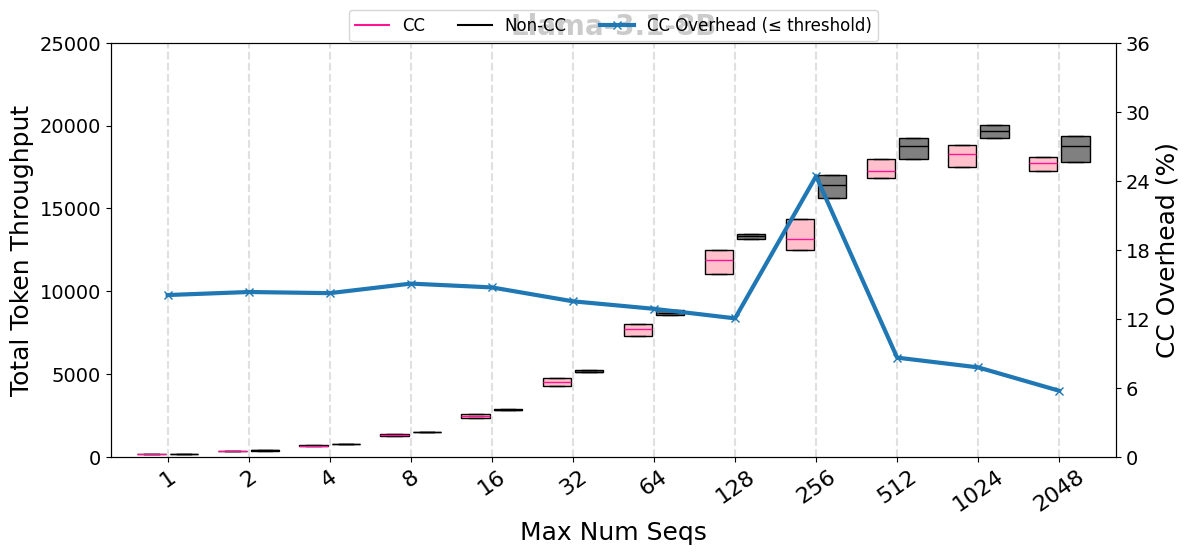

In [14]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.ticker as mticker

# --- Assumes you already have sglang_sig_df in scope ---

# Single model
model_order = ["meta-llama/Llama-3.1-8B"]

solid_thresholds = {
    model_order[0]: 2048,
}

# Create a single figure/axes
fig, ax1 = plt.subplots(figsize=(12, 6))

model = model_order[0]
model_df = sglang_sig_df[sglang_sig_df["model_path"] == model].copy()

# x-axis positions and labels
x_labels = model_df["max_num_seqs"].tolist()
base_pos = list(range(len(x_labels)))

# Build boxplot dicts
cc_boxes = []
noncc_boxes = []
for i in range(len(model_df)):
    cc_boxes.append({
        'med':    model_df.iloc[i]["mean_cc"],
        'q1':     model_df.iloc[i]["min_cc"],
        'q3':     model_df.iloc[i]["max_cc"],
        'whislo': model_df.iloc[i]["min_cc"],
        'whishi': model_df.iloc[i]["max_cc"],
        'fliers': []
    })
    noncc_boxes.append({
        'med':    model_df.iloc[i]["mean_noncc"],
        'q1':     model_df.iloc[i]["min_noncc"],
        'q3':     model_df.iloc[i]["max_noncc"],
        'whislo': model_df.iloc[i]["min_noncc"],
        'whishi': model_df.iloc[i]["max_noncc"],
        'fliers': []
    })

# Offsets for side-by-side boxes
cc_pos = [p - 0.2 for p in base_pos]
noncc_pos = [p + 0.2 for p in base_pos]

# Boxplots
ax1.bxp(
    cc_boxes, positions=cc_pos, widths=0.35, showfliers=False, patch_artist=True,
    boxprops=dict(facecolor="pink"), medianprops=dict(color="deeppink")
)
ax1.bxp(
    noncc_boxes, positions=noncc_pos, widths=0.35, showfliers=False, patch_artist=True,
    boxprops=dict(facecolor="gray"), medianprops=dict(color="black")
)

# X/Y formatting
ax1.set_xticks(base_pos)
ax1.set_xticklabels([str(x) for x in x_labels], rotation=35, fontsize=16)
ax1.xaxis.set_major_locator(ticker.FixedLocator(base_pos))  # prevent auto-skipping
ax1.yaxis.set_major_locator(ticker.MultipleLocator(5000))
ax1.set_ylim(bottom=0, top=25000)
ax1.set_ylabel("Total Token Throughput", fontsize=18)
ax1.set_xlabel("Max Num Seqs", fontsize=18)
ax1.set_title(model.split('/')[-1], fontsize=20, fontweight="bold")
ax1.tick_params(axis='y', labelsize=14)

# Vertical guides
for pos in base_pos:
    ax1.axvline(x=pos, color="lightgray", linestyle="--", alpha=0.7)

# Secondary axis for CC Overhead (%)
ax2 = ax1.twinx()
threshold = solid_thresholds.get(model, 128)

df_solid = model_df[model_df["max_num_seqs"] <= threshold]
df_dashed = model_df[model_df["max_num_seqs"] > threshold]

if not df_solid.empty:
    x_solid = [x_labels.index(x) for x in df_solid["max_num_seqs"]]
    y_solid = (df_solid["cc_overhead"] - 1) * 100
    ax2.plot(x_solid, y_solid, linestyle='-', marker='x', linewidth=3, label="CC Overhead (≤ threshold)")

if not df_dashed.empty:
    x_dashed = [x_labels.index(x) for x in df_dashed["max_num_seqs"]]
    y_dashed = (df_dashed["cc_overhead"] - 1) * 100
    ax2.plot(x_dashed, y_dashed, linestyle='--', marker='x', linewidth=1, label="CC Overhead (> threshold)")

# Connect solid→dashed if both exist
if not df_solid.empty and not df_dashed.empty:
    last_x_solid = x_labels.index(df_solid["max_num_seqs"].max())
    first_x_dashed = x_labels.index(df_dashed["max_num_seqs"].min())
    last_y_solid = ((df_solid[df_solid["max_num_seqs"] == df_solid["max_num_seqs"].max()]["cc_overhead"].values[0]) - 1) * 100
    first_y_dashed = ((df_dashed[df_dashed["max_num_seqs"] == df_dashed["max_num_seqs"].min()]["cc_overhead"].values[0]) - 1) * 100
    ax2.plot([last_x_solid, first_x_dashed], [last_y_solid, first_y_dashed], linestyle="--", linewidth=1)

ax2.set_ylabel("CC Overhead (%)", fontsize=18)
ax2.set_ylim(bottom=0, top=36)
ax2.tick_params(axis='y', labelsize=14)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
ax2.yaxis.set_major_locator(ticker.MultipleLocator(6))

# Legends (combine CC/Non-CC boxes + overhead line)
handles_boxes = [
    plt.Line2D([], [], color="deeppink", label="CC"),
    plt.Line2D([], [], color="black", label="Non-CC"),
]
handles_lines, labels_lines = ax2.get_legend_handles_labels()
all_handles = handles_boxes + handles_lines
ax1.legend(all_handles, [h.get_label() for h in all_handles], loc='upper center', ncols=3, fontsize=12, frameon=True, bbox_to_anchor=(0.5, 1.10))

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


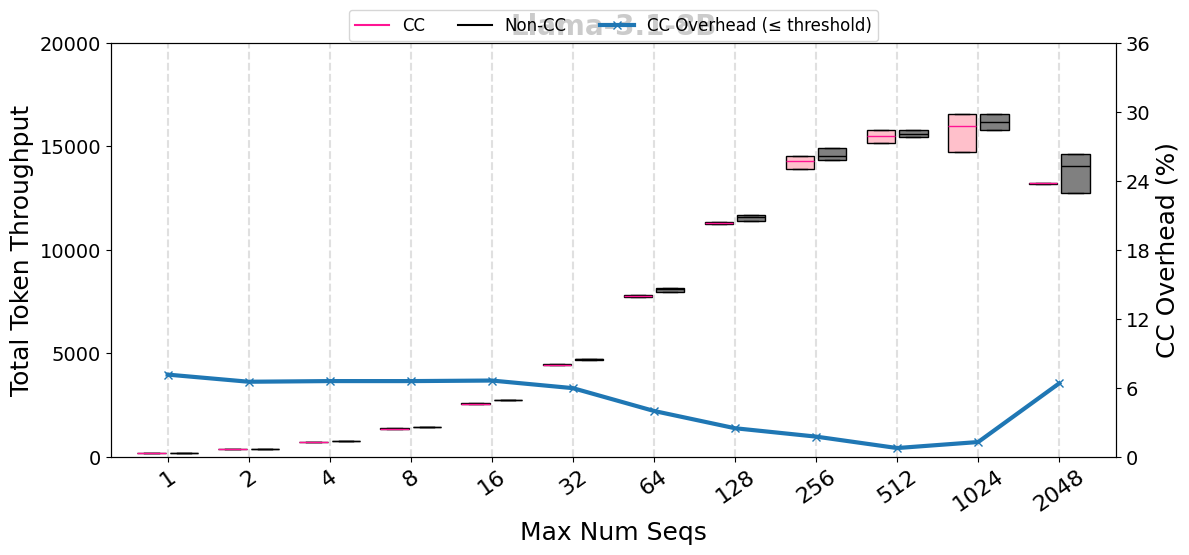

In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.ticker as mticker

# --- Assumes you already have vllm_sig_df in scope ---

# Single model
model_order = ["meta-llama/Llama-3.1-8B"]

solid_thresholds = {
    model_order[0]: 2048,
}

# Create a single figure/axes
fig, ax1 = plt.subplots(figsize=(12, 6))

model = model_order[0]
model_df = vllm_sig_df[vllm_sig_df["model_path"] == model].copy()

# x-axis positions and labels
x_labels = model_df["max_num_seqs"].tolist()
base_pos = list(range(len(x_labels)))

# Build boxplot dicts
cc_boxes = []
noncc_boxes = []
for i in range(len(model_df)):
    cc_boxes.append({
        'med':    model_df.iloc[i]["mean_cc"],
        'q1':     model_df.iloc[i]["min_cc"],
        'q3':     model_df.iloc[i]["max_cc"],
        'whislo': model_df.iloc[i]["min_cc"],
        'whishi': model_df.iloc[i]["max_cc"],
        'fliers': []
    })
    noncc_boxes.append({
        'med':    model_df.iloc[i]["mean_noncc"],
        'q1':     model_df.iloc[i]["min_noncc"],
        'q3':     model_df.iloc[i]["max_noncc"],
        'whislo': model_df.iloc[i]["min_noncc"],
        'whishi': model_df.iloc[i]["max_noncc"],
        'fliers': []
    })

# Offsets for side-by-side boxes
cc_pos = [p - 0.2 for p in base_pos]
noncc_pos = [p + 0.2 for p in base_pos]

# Boxplots
ax1.bxp(
    cc_boxes, positions=cc_pos, widths=0.35, showfliers=False, patch_artist=True,
    boxprops=dict(facecolor="pink"), medianprops=dict(color="deeppink")
)
ax1.bxp(
    noncc_boxes, positions=noncc_pos, widths=0.35, showfliers=False, patch_artist=True,
    boxprops=dict(facecolor="gray"), medianprops=dict(color="black")
)

# X/Y formatting
ax1.set_xticks(base_pos)
ax1.set_xticklabels([str(x) for x in x_labels], rotation=35, fontsize=16)
ax1.xaxis.set_major_locator(ticker.FixedLocator(base_pos))  # prevent auto-skipping
ax1.yaxis.set_major_locator(ticker.MultipleLocator(5000))
ax1.set_ylim(bottom=0, top=20000)
ax1.set_ylabel("Total Token Throughput", fontsize=18)
ax1.set_xlabel("Max Num Seqs", fontsize=18)
ax1.set_title(model.split('/')[-1], fontsize=20, fontweight="bold")
ax1.tick_params(axis='y', labelsize=14)

# Vertical guides
for pos in base_pos:
    ax1.axvline(x=pos, color="lightgray", linestyle="--", alpha=0.7)

# Secondary axis for CC Overhead (%)
ax2 = ax1.twinx()
threshold = solid_thresholds.get(model, 128)

df_solid = model_df[model_df["max_num_seqs"] <= threshold]
df_dashed = model_df[model_df["max_num_seqs"] > threshold]

if not df_solid.empty:
    x_solid = [x_labels.index(x) for x in df_solid["max_num_seqs"]]
    y_solid = (df_solid["cc_overhead"] - 1) * 100
    ax2.plot(x_solid, y_solid, linestyle='-', marker='x', linewidth=3, label="CC Overhead (≤ threshold)")

if not df_dashed.empty:
    x_dashed = [x_labels.index(x) for x in df_dashed["max_num_seqs"]]
    y_dashed = (df_dashed["cc_overhead"] - 1) * 100
    ax2.plot(x_dashed, y_dashed, linestyle='--', marker='x', linewidth=1, label="CC Overhead (> threshold)")

# Connect solid→dashed if both exist
if not df_solid.empty and not df_dashed.empty:
    last_x_solid = x_labels.index(df_solid["max_num_seqs"].max())
    first_x_dashed = x_labels.index(df_dashed["max_num_seqs"].min())
    last_y_solid = ((df_solid[df_solid["max_num_seqs"] == df_solid["max_num_seqs"].max()]["cc_overhead"].values[0]) - 1) * 100
    first_y_dashed = ((df_dashed[df_dashed["max_num_seqs"] == df_dashed["max_num_seqs"].min()]["cc_overhead"].values[0]) - 1) * 100
    ax2.plot([last_x_solid, first_x_dashed], [last_y_solid, first_y_dashed], linestyle="--", linewidth=1)

ax2.set_ylabel("CC Overhead (%)", fontsize=18)
ax2.set_ylim(bottom=0, top=36)
ax2.tick_params(axis='y', labelsize=14)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
ax2.yaxis.set_major_locator(ticker.MultipleLocator(6))

# Legends (combine CC/Non-CC boxes + overhead line)
handles_boxes = [
    plt.Line2D([], [], color="deeppink", label="CC"),
    plt.Line2D([], [], color="black", label="Non-CC"),
]
handles_lines, labels_lines = ax2.get_legend_handles_labels()
all_handles = handles_boxes + handles_lines
ax1.legend(all_handles, [h.get_label() for h in all_handles], loc='upper center', ncols=3, fontsize=12, frameon=True, bbox_to_anchor=(0.5, 1.10))

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
